In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [ ]:
df=pd.read_csv("titanic.csv")

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()
df["Sex"]=le.fit_transform(df["Sex"])

In [ ]:
X = df.drop("Sex", axis=1)
y = df["Sex"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Drop non-numerical columns and handle missing values before fitting
X_train_processed = X_train.drop(columns=['Name', 'Ticket', 'Cabin', 'Embarked'], errors='ignore')
X_test_processed = X_test.drop(columns=['Name', 'Ticket', 'Cabin', 'Embarked'], errors='ignore')

# Impute missing 'Age' values with the mean
X_train_processed['Age'].fillna(X_train_processed['Age'].mean(), inplace=True)
X_test_processed['Age'].fillna(X_test_processed['Age'].mean(), inplace=True)

log_reg = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
log_reg.fit(X_train_processed, y_train)

/tmp/ipykernel_1878/2187580870.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_processed['Age'].fillna(X_train_processed['Age'].mean(), inplace=True)
/tmp/ipykernel_1878/2187580870.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# Logistic Regression
y_pred_log = log_reg.predict(X_test_processed) # Changed X_test to X_test_processed
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Female","Male"]))


Logistic Regression Results
Accuracy: 0.7761194029850746
              precision    recall  f1-score   support

      Female       0.69      0.74      0.71       101
        Male       0.84      0.80      0.82       167

    accuracy                           0.78       268
   macro avg       0.76      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



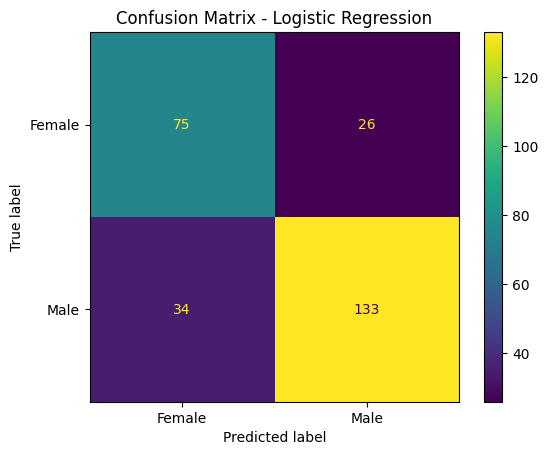

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [13]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
# Sample Titanic Dataset
data = {
    'Pclass': [3, 1, 3, 1],
    'Age': [22, 38, 26, 35],
    'Fare': [7.25, 71.83, 7.92, 53.10],
    'Sex': [0, 1, 1, 1],
    'SibSp': [1, 1, 0, 1],
    'Parch': [0, 0, 0, 0],
    'Embarked': [0, 1, 0, 0],
    'Survived': [0, 1, 1, 1]
}
# Convert into DataFrame
df = pd.DataFrame(data)
# Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']
# Train Model
log_reg = LogisticRegression()
log_reg.fit(X, y)
# ------------------------------
# External Prediction
# ------------------------------
new_data = [[0, 13.5, 6.2, 1, 1, 0, 1]]
# Create DataFrame
new_data_df = pd.DataFrame(new_data, columns=X.columns)
# Prediction
prediction = log_reg.predict(new_data_df)
# Output
if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Not Survived")

Passenger Not Survived
